In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("../Data/powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
X = df.drop(["PE"], axis = 1)
y = df["PE"]

In [5]:
#Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 42
)

In [6]:
#Scaling the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
import torch
import torch.nn as nn

In [8]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [9]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)


In [11]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle= True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle= True)

### Deep Learning

In [12]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            #1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            #2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            #output layer
            nn.Linear(6,1),
        )

    def forward(self, x):
        return self.model(x)

In [13]:
import torch.optim as optim

model = ANN()

#loss , optimizer

crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [14]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/100 ==> train loss = 206914.9783203125 & val loss = 206155.203125
epoch 2/100 ==> train loss = 203897.5099609375 & val loss = 199658.8125
epoch 3/100 ==> train loss = 192108.88072916667 & val loss = 182054.359375
epoch 4/100 ==> train loss = 168382.82434895833 & val loss = 152524.8125
epoch 5/100 ==> train loss = 134434.88382161458 & val loss = 115392.3671875
epoch 6/100 ==> train loss = 96599.01321614583 & val loss = 78470.2265625
epoch 7/100 ==> train loss = 63005.72497558594 & val loss = 49687.48046875
epoch 8/100 ==> train loss = 40000.97357584636 & val loss = 32483.388671875
epoch 9/100 ==> train loss = 27734.774820963543 & val loss = 24346.32421875
epoch 10/100 ==> train loss = 22184.065006510416 & val loss = 20394.755859375
epoch 11/100 ==> train loss = 19127.64326578776 & val loss = 17801.619140625
epoch 12/100 ==> train loss = 16682.800111897788 & val loss = 15496.6201171875
epoch 13/100 ==> train loss = 14451.722625732422 & val loss = 13272.3232421875
epoch 14/100 ==>

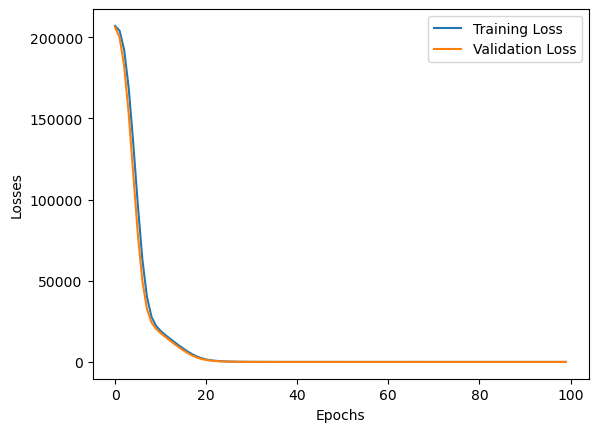

In [15]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [18]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [19]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 20.483341217041016
Testing MSE: 18.773605346679688


In [20]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.934391091998616


In [21]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.337097,433.27
1,436.966583,438.16
2,461.306702,458.42
3,476.123230,480.82
4,435.529663,441.41
...,...,...
1909,451.254913,456.70
1910,431.725342,438.04
1911,467.420288,467.80
1912,431.173340,437.14
